# 01_collection_phase1_v4 — DART 사업보고서 정밀 수집 (lxml SECTION-1 직접 추출)

> **작성자**: 이동원 · **작성일**: 2026-05-16 · **버전**: v4
> **이전 버전**: `01_collection_phase1_v3.ipynb` (II/IV/VI 모두 0자 — 정규식 헤딩 매칭이 목차·본문 구분 실패)
> **벤치마킹**: [dart-fss-text](https://github.com/jaepil-choi/dart-fss-text) (XML + 정규식 + fuzzy matching 조합, section_code 체계)
> **보고서**: `members/이동원/reports/01_collection/01_collection_phase1_v4_보고서.md`

## v4 핵심 변경 (v3 → v4)

| 영역 | v3 (실패) | v4 (정답) |
|---|---|---|
| 헤딩 추출 | itertext 평탄화 → 정규식 매칭 | **lxml `findall('.//SECTION-1')` 14 노드 직접 순회** |
| 식별 | 정규식 패턴 6~8개 | **TITLE 텍스트 매칭 + AASSOCNOTE 보조** |
| 결과 | II/IV/VI 모두 0자 ❌ | II/IV/VI 정합 길이 ✅ (예상) |
| 출력 스키마 | label만 (II, IV, VI) | **section_code 체계 (020000, 040000, 060000)** + dart-fss-text 호환 |
| 표 처리 | itertext 평탄화 | 동일 (MVP — 표 분리는 02_preprocessing에서) |

## 본 노트북이 처리하는 가이드 단계 (가이드 02 line 153~158)

가이드 매핑은 v3과 동일 (Step 1~6 = 가이드 1~6번 단계). **Step 7 (섹션 발췌)만 핵심 교체**.


---

## Step 0 · 가이드 매핑·위반금지 8항목 사전 점검

| # | 위반금지 | 가이드 라인 | v4 적용 위치 |
|---|---|---|---|
| 1 | 실패 행 가짜 0 채우기 ❌ | line 172, 286 | Step 5 `FAIL_NO_BUSINESS_REPORT` · Step 7 `FAIL_SECTION_NOT_FOUND` · Step 10 status 세분화 |
| 2 | viewer 우회 ❌ | line 67, 94 | Step 5 document.xml만 사용 · Step 9 viewer 검증 |
| 3 | MCP/LLM 추출 결과 그대로 신뢰 ❌ | line 94 | Step 9 viewer 5 sample 수동 검증 |
| 4 | API key 출력 노출 ❌ | line 216-222 | Step 1 `mask_key()` + 키 후보 리스트 (`API_KEY` 포함) |
| 5 | raw 미보존 ❌ | line 155 | Step 5 `data/raw/*.zip` 보존 |
| 6 | 진단 부재 ❌ | line 143-146, 170-172 | Step 5·6·7 진단 출력 (SECTION-1 14개 모두 표 형태) |
| 7 | silent 오매칭 (회사명 join) ❌ | line 35 | Step 2 stock_code 기준 |
| 8 | 평가 기준 부재 ❌ | line 145 | Step 9 viewer 5/5 기준 + Step 11 self-check |

**가이드 line 18 의도(사업보고서 II/IV/VI 섹션) 충실 구현:**
- Step 5: zip 안 DOCUMENT-NAME으로 사업보고서 본문 XML만 선택 (Fix #0 유지)
- Step 7: lxml로 SECTION-1 노드 직접 추출 → II(020000), IV(040000), VI(060000) 정확히 식별 (**Fix #6·#7 신규**)


---

## Step 1 · 환경 셋업 + API key 안전 (가이드 line 216-222)

v3과 동일. `KEY_CANDIDATES`에 `API_KEY` 포함 (이동원 .env 환경).


In [2]:
# Colab 사용자만 주석 해제
# !pip install python-dotenv pandas requests lxml tqdm matplotlib pyarrow rapidfuzz

import os, sys, re, json, time, zipfile, warnings
from io import BytesIO
from pathlib import Path
from datetime import datetime

import requests
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from dotenv import load_dotenv

# v4 필수: lxml (SECTION-1 직접 순회)
from lxml import etree

# v4 선택: rapidfuzz (Fix #9 fuzzy matching — Phase 2부터 활성화 가능)
try:
    from rapidfuzz import fuzz
    RAPIDFUZZ_AVAILABLE = True
except ImportError:
    RAPIDFUZZ_AVAILABLE = False
    print("ℹ️ rapidfuzz 미설치 — fuzzy matching 비활성. Phase 2 이전 `pip install rapidfuzz` 권장.")

# 한글 폰트
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
for f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']:
    try:
        matplotlib.rcParams['font.family'] = f
        break
    except Exception:
        pass

warnings.filterwarnings('ignore')


def find_project_root() -> Path:
    """v2 Fix #1 — cwd부터 상위 경로에서 anchor 파일 탐색."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'data' / 'company_master.csv').exists():
            return candidate
    raise FileNotFoundError("project root not found")


def mask_key(key: str) -> str:
    """위반금지 #4 — API key 마스킹."""
    return f"{key[:4]}...len={len(key)}" if key else '(empty)'


ROOT = find_project_root()
print(f"📍 ROOT: {ROOT}")

load_dotenv(ROOT / '.env')

# ⚠️ 이동원 .env는 `API_KEY` 이름. 후보 리스트로 견고하게.
KEY_CANDIDATES = ['OPENDART_API_KEY', 'API_KEY', 'DART_API_KEY']
API_KEY = next((os.getenv(k) for k in KEY_CANDIDATES if os.getenv(k)), None)
assert API_KEY, f"❌ {KEY_CANDIDATES} 중 어느 것도 .env에 없습니다."
print(f"✅ API key 로드 완료 ({mask_key(API_KEY)})")

DIR_RAW = ROOT / 'data' / 'raw'
DIR_INTERIM = ROOT / 'data' / 'interim'
DIR_CACHE = ROOT / 'data' / 'cache'
DIR_LOGS = ROOT / 'logs'
for d in [DIR_RAW, DIR_INTERIM, DIR_CACHE, DIR_LOGS]:
    d.mkdir(parents=True, exist_ok=True)
print(f"\n📁 출력 디렉토리 준비 완료")
print(f"   rapidfuzz: {RAPIDFUZZ_AVAILABLE}")


📍 ROOT: c:\Users\kik32\workspace\unstructured-data-processing-final-project
✅ API key 로드 완료 (0e1e...len=40)

📁 출력 디렉토리 준비 완료
   rapidfuzz: True


---

## Step 1+ · section_code 사전 정의 (**Fix #7 신규** — dart-fss-text 호환)

DART 사업보고서의 공식 hierarchical 식별자. AASSOCNOTE 형식 `D-0-X-Y-Z`는 section_code `0X0Y0Z` (혹은 `0XYZ00`)로 변환. ESG primary target은 II(020000), IV(040000), VI(060000) — 가이드 line 18.


In [3]:
# DART 사업보고서 SECTION-1 14개 + section_code 매핑
# (Samsung 2024 검증 결과 기반)
SECTION_CODE_MAP = {
    'CEO_CERT':  ('TTL_CEO_CERT', '대표이사 등의 확인'),
    'I':   ('010000', 'I. 회사의 개요'),
    'II':  ('020000', 'II. 사업의 내용'),                    # ⭐ ESG target
    'III': ('030000', 'III. 재무에 관한 사항'),
    'IV':  ('040000', 'IV. 이사의 경영진단 및 분석의견'),    # ⭐ ESG target
    'V':   ('050000', 'V. 회계감사인의 감사의견 등'),
    'VI':  ('060000', 'VI. 이사회 등 회사의 기관에 관한 사항'),  # ⭐ ESG target
    'VII': ('070000', 'VII. 주주에 관한 사항'),
    'VIII':('080000', 'VIII. 임원 및 직원 등에 관한 사항'),
    'IX':  ('090000', 'IX. 계열회사 등에 관한 사항'),
    'X':   ('100000', 'X. 대주주 등과의 거래내용'),
    'XI':  ('110000', 'XI. 그 밖에 투자자 보호를 위하여 필요한 사항'),
    'XII': ('TTL_APPENDIX', 'XII. 상세표'),
    'EXPERT_CERT': ('', '전문가의 확인'),
}

# ESG primary target (가이드 line 18)
ESG_TARGET_LABELS = ['II', 'IV', 'VI']

# TITLE 텍스트 매칭용 패턴 (AASSOCNOTE 빈 값 케이스 대응 — VI/VIII/I 등)
TITLE_PATTERNS = {
    'I':   [r'^I\.\s', r'^Ⅰ\.\s', r'회사의\s*개요'],
    'II':  [r'^II\.\s', r'^Ⅱ\.\s', r'^2\.\s', r'사업의\s*내용'],
    'III': [r'^III\.\s', r'^Ⅲ\.\s', r'^3\.\s', r'재무에\s*관한\s*사항'],
    'IV':  [r'^IV\.\s', r'^Ⅳ\.\s', r'^4\.\s', r'이사의\s*경영진단', r'이사.*경영진단'],
    'V':   [r'^V\.\s', r'^Ⅴ\.\s', r'^5\.\s', r'감사인의\s*감사의견', r'회계감사인'],
    'VI':  [r'^VI\.\s', r'^Ⅵ\.\s', r'^6\.\s', r'이사회\s*등.*기관', r'이사회.*회사의\s*기관'],
    'VII': [r'^VII\.\s', r'^Ⅶ\.\s', r'^7\.\s', r'주주에\s*관한\s*사항'],
    'VIII':[r'^VIII\.\s', r'^Ⅷ\.\s', r'^8\.\s', r'임원\s*및\s*직원'],
    'IX':  [r'^IX\.\s', r'^Ⅸ\.\s', r'^9\.\s', r'계열회사'],
    'X':   [r'^X\.\s', r'^Ⅹ\.\s', r'^10\.\s', r'대주주.*거래내용'],
    'XI':  [r'^XI\.\s', r'^Ⅺ\.\s', r'^11\.\s', r'그\s*밖.*투자자\s*보호'],
}


def parse_aassocnote(aassoc: str) -> tuple:
    """`D-0-2-0-0` 형식을 (label, section_code)로 파싱.

    Returns:
        (label, section_code) or (None, None)
    """
    if not aassoc or not aassoc.startswith('D-'):
        return (None, None)
    parts = aassoc.split('-')
    if len(parts) < 5:
        return (None, None)
    try:
        # D-0-X-Y-Z → label은 X (로마 숫자), section_code는 0X0Y0Z
        x, y, z = int(parts[2]), int(parts[3]), int(parts[4])
        roman = ['', 'I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X', 'XI', 'XII'][x] if x < 13 else None
        if roman is None:
            return (None, None)
        # 6자리 section_code: 2자리씩 (X, Y, Z 각 2자리 zero-pad)
        section_code = f'{x:02d}{y:02d}{z:02d}'
        return (roman, section_code)
    except (ValueError, IndexError):
        return (None, None)


def match_title_to_label(title_text: str) -> str:
    """TITLE 텍스트를 SECTION-1 label로 매칭 (AASSOCNOTE 보조)."""
    if not title_text:
        return None
    text = title_text.strip()
    for label, patterns in TITLE_PATTERNS.items():
        for pat in patterns:
            if re.search(pat, text):
                return label
    return None


# section_code 사전 저장 (logs에 yaml 형태로 — 02_preprocessing 재사용)
section_codes_path = DIR_LOGS / 'dart_section_codes_v4.json'
section_codes_path.write_text(
    json.dumps({
        'description': 'DART 사업보고서 SECTION-1 매핑 (dart-fss-text 호환)',
        'esg_target_labels': ESG_TARGET_LABELS,
        'sections': {
            label: {'section_code': code, 'title': title}
            for label, (code, title) in SECTION_CODE_MAP.items()
        }
    }, ensure_ascii=False, indent=2),
    encoding='utf-8'
)
print(f"💾 section_code 사전 저장: {section_codes_path.name}")
print(f"\nESG primary target (가이드 line 18):")
for label in ESG_TARGET_LABELS:
    code, title = SECTION_CODE_MAP[label]
    print(f"   {label} = section_code={code} | {title}")


💾 section_code 사전 저장: dart_section_codes_v4.json

ESG primary target (가이드 line 18):
   II = section_code=020000 | II. 사업의 내용
   IV = section_code=040000 | IV. 이사의 경영진단 및 분석의견
   VI = section_code=060000 | VI. 이사회 등 회사의 기관에 관한 사항


---

## Step 2 · 파일럿 대상 설정 + company_master 검증 (v3과 동일)

가이드 line 21-35 (식별자), line 35 (silent 오매칭 금지), line 38 (esg_year=fiscal+1), line 117 (381).


In [4]:
PILOT_STOCK = '005930'
PILOT_FISCAL = 2024
PILOT_ESG_YEAR = PILOT_FISCAL + 1

cm = pd.read_csv(ROOT / 'data' / 'company_master.csv', dtype={'stock_code': str})
print(f"📊 company_master: {len(cm)}행 / {cm['stock_code'].nunique()} unique stock / fiscal_year={sorted(cm['fiscal_year'].unique().tolist())}")

pilot_rows = cm[(cm['stock_code'] == PILOT_STOCK) & (cm['fiscal_year'] == PILOT_FISCAL)]
assert len(pilot_rows) == 1
pilot_row = pilot_rows.iloc[0]
print(f"\n🎯 파일럿: stock={PILOT_STOCK} / fiscal={PILOT_FISCAL} / esg={PILOT_ESG_YEAR}")
pilot_row.to_frame()


📊 company_master: 381행 / 127 unique stock / fiscal_year=[2022, 2023, 2024]

🎯 파일럿: stock=005930 / fiscal=2024 / esg=2025


,2
company_name,삼성전자
corp_code,NaN
stock_code,005930
industry,전기전자
fiscal_year,2024
report_code,11011
rcept_no,NaN
esg_source,한국ESG기준원
esg_grade,A
e_grade,B+


---

## Step 3 · stock_code → corp_code (v3과 동일, 가이드 line 153)


In [5]:
def fetch_corp_code_map(api_key, cache_dir):
    cache = cache_dir / 'corp_code_map.parquet'
    if cache.exists():
        df = pd.read_parquet(cache)
        print(f"📦 캐시 hit: {cache.name} ({len(df):,}건)")
        return df
    res = requests.get("https://opendart.fss.or.kr/api/corpCode.xml",
                       params={'crtfc_key': api_key}, timeout=30)
    res.raise_for_status()
    with zipfile.ZipFile(BytesIO(res.content)) as zf:
        xml_bytes = zf.read(zf.namelist()[0])
    root = etree.fromstring(xml_bytes)
    rows = [{
        'corp_code': (el.findtext('corp_code') or '').strip(),
        'corp_name': (el.findtext('corp_name') or '').strip(),
        'stock_code': (el.findtext('stock_code') or '').strip(),
    } for el in root.findall('list')]
    df = pd.DataFrame(rows)
    df = df[df['stock_code'].str.len() == 6]
    df.to_parquet(cache, index=False)
    return df


corp_map = fetch_corp_code_map(API_KEY, DIR_CACHE)
match = corp_map[corp_map['stock_code'] == PILOT_STOCK]
assert len(match) == 1
PILOT_CORP = match.iloc[0]['corp_code']
print(f"✅ {PILOT_STOCK} → {PILOT_CORP} ({match.iloc[0]['corp_name']})")


📦 캐시 hit: corp_code_map.parquet (3,965건)
✅ 005930 → 00126380 (삼성전자)


---

## Step 4 · corp_code → rcept_no + 정정공시 이력 (v3과 동일, 세분화 축 B)


In [6]:
def find_rcept_no_v4(api_key, corp_code, fiscal_year):
    params_final = {
        'crtfc_key': api_key, 'corp_code': corp_code,
        'bgn_de': f'{fiscal_year + 1}0101', 'end_de': f'{fiscal_year + 1}1231',
        'pblntf_detail_ty': 'A001', 'last_reprt_at': 'Y', 'page_count': '100',
    }
    res = requests.get('https://opendart.fss.or.kr/api/list.json', params=params_final, timeout=20)
    res.raise_for_status()
    rows = res.json().get('list', [])
    target = f'({fiscal_year}.12)'
    finals = [r for r in rows if '사업보고서' in r.get('report_nm','') and target in r.get('report_nm','')]
    if not finals:
        raise RuntimeError(f"FAIL_LIST — 사업보고서 {target} 없음")
    sel = finals[0]
    selected = {
        'rcept_no': sel['rcept_no'], 'rcept_dt': sel['rcept_dt'],
        'report_nm': sel['report_nm'],
        'viewer_url': f"https://dart.fss.or.kr/dsaf001/main.do?rcpNo={sel['rcept_no']}",
    }
    # 정정공시 이력
    params_all = {**params_final, 'last_reprt_at': 'N'}
    res2 = requests.get('https://opendart.fss.or.kr/api/list.json', params=params_all, timeout=20)
    all_cand = []
    if res2.status_code == 200:
        for r in res2.json().get('list', []):
            if '사업보고서' in r.get('report_nm','') and target in r.get('report_nm',''):
                all_cand.append({'rcept_no': r['rcept_no'], 'rcept_dt': r['rcept_dt'], 'report_nm': r['report_nm']})
    return {'selected': selected, 'all_candidates': all_cand}


result_step4 = find_rcept_no_v4(API_KEY, PILOT_CORP, PILOT_FISCAL)
PILOT_RCEPT = result_step4['selected']['rcept_no']
VIEWER_URL = result_step4['selected']['viewer_url']
print(f"✅ rcept_no={PILOT_RCEPT} / viewer={VIEWER_URL}")
n_corr = max(0, len(result_step4['all_candidates']) - 1)
print(f"📜 정정공시 이력 (가이드 line 69): {n_corr}건")


✅ rcept_no=20250311001085 / viewer=https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20250311001085
📜 정정공시 이력 (가이드 line 69): 0건


---

## Step 5 · document.xml zip + DOCUMENT-NAME type 판별 (v3 Fix #0 유지)

가이드 line 155, line 18. zip raw 보존 + 사업보고서 본문 XML primary 선택.


In [7]:
DOC_TYPE_PATTERN = re.compile(r'<DOCUMENT-NAME[^>]*>([^<]+)</DOCUMENT-NAME>', re.UNICODE)


def download_document_xml_v4(api_key, rcept_no, stock, year, raw_dir):
    zip_path = raw_dir / f'{stock}_{year}_disclosure.zip'
    if zip_path.exists() and zip_path.stat().st_size > 1024:
        zip_bytes = zip_path.read_bytes()
        print(f"📦 캐시 hit: {zip_path.name} ({zip_path.stat().st_size/1024:.1f} KB)")
    else:
        res = requests.get('https://opendart.fss.or.kr/api/document.xml',
                           params={'crtfc_key': api_key, 'rcept_no': rcept_no}, timeout=60)
        res.raise_for_status()
        zip_bytes = res.content
        zip_path.write_bytes(zip_bytes)
        print(f"📥 다운로드: {zip_path.name} ({len(zip_bytes)/1024:.1f} KB)")

    sources = {'사업보고서': [], '연결감사보고서': [], '감사보고서': [], 'unknown': []}
    with zipfile.ZipFile(BytesIO(zip_bytes)) as zf:
        for name in zf.namelist():
            xml = zf.read(name).decode('utf-8', errors='ignore')
            m = DOC_TYPE_PATTERN.search(xml)
            dt = m.group(1).strip() if m else 'unknown'
            key = dt if dt in sources else 'unknown'
            sources[key].append((name, xml, dt))
            print(f"   - {name}: {len(xml):>10,}자 | DOCUMENT-NAME: {dt}")

    if sources['사업보고서']:
        primary = max(sources['사업보고서'], key=lambda x: len(x[1]))
        print(f"\n⭐ primary: {primary[0]} ({len(primary[1]):,}자)")
    elif sources['unknown']:
        primary = max(sources['unknown'], key=lambda x: len(x[1]))
        print(f"\n⚠️ '사업보고서' DOCUMENT-NAME 없음 — unknown fallback")
    else:
        raise RuntimeError("FAIL_NO_BUSINESS_REPORT")
    return {'zip_path': zip_path, 'sources': sources, 'primary': primary, 'n_xml_files': len(zf.namelist())}


result_step5 = download_document_xml_v4(API_KEY, PILOT_RCEPT, PILOT_STOCK, PILOT_FISCAL, DIR_RAW)
PRIMARY_NAME, PRIMARY_XML, PRIMARY_TYPE = result_step5['primary']


📦 캐시 hit: 005930_2024_disclosure.zip (660.2 KB)
   - 20250311001085_00761.xml:    623,804자 | DOCUMENT-NAME: 연결감사보고서
   - 20250311001085_00760.xml:    531,069자 | DOCUMENT-NAME: 감사보고서
   - 20250311001085.xml:  5,780,877자 | DOCUMENT-NAME: 사업보고서

⭐ primary: 20250311001085.xml (5,780,877자)


---

## Step 5+ · 보조 보고서 별도 보존 (세분화 축 A, v3과 동일)


In [8]:
def save_aux_sources(sources, stock, year, interim_dir):
    name_map = {'연결감사보고서': 'aux_audit_consolidated', '감사보고서': 'aux_audit_separate'}
    saved = {}
    for dt, suffix in name_map.items():
        items = sources.get(dt, [])
        if not items:
            saved[dt] = None
            continue
        out = {'doc_type': dt, 'stock_code': stock, 'fiscal_year': year,
               'files': [{'filename': fn, 'doc_name_in_xml': d, 'xml_text_length': len(xt), 'xml_text': xt}
                         for fn, xt, d in items]}
        path = interim_dir / f'{stock}_{year}_{suffix}.json'
        path.write_text(json.dumps(out, ensure_ascii=False), encoding='utf-8')
        saved[dt] = path
        print(f"💾 [{dt}] {path.name} ({path.stat().st_size/1024:.1f} KB)")
    return saved


aux_saved = save_aux_sources(result_step5['sources'], PILOT_STOCK, PILOT_FISCAL, DIR_INTERIM)


💾 [연결감사보고서] 005930_2024_aux_audit_consolidated.json (763.7 KB)
💾 [감사보고서] 005930_2024_aux_audit_separate.json (648.7 KB)


---

## Step 6 · 🔥 **v4 핵심** · lxml SECTION-1 직접 추출 (Fix #6 + #7 신규)

**가이드 line 156-157**: XML → 텍스트 추출 + II/IV/VI 섹션 발췌
**Fix #6 (신규)**: `root.findall('.//SECTION-1')`로 14개 노드 순회 — v3의 정규식 평탄화 매칭 폐기
**Fix #7 (신규)**: section_code 체계 (020000=II, 040000=IV, 060000=VI) — dart-fss-text 호환
**보조**: TITLE 텍스트 매칭 (AASSOCNOTE 빈 값 케이스, VI/I/VIII 대응) + fuzzy fallback (rapidfuzz, P1)

### 동작
1. lxml로 사업보고서 XML 파싱 (`recover=True, huge_tree=True`)
2. `root.findall('.//SECTION-1')` → 14 노드 (사업보고서 I~XII + 표지·확인)
3. 각 SECTION-1의 첫 `<TITLE>` 노드에서:
   - AASSOCNOTE 속성 (`D-0-2-0-0` → label `II`) — 우선
   - TITLE 텍스트 매칭 (`'II. 사업의 내용'` → label `II`) — 보조
4. 매칭된 SECTION-1 노드 안에서 `itertext()` → **본문 + 표** 모두 평탄화된 텍스트 추출
5. 결과를 section_code 체계로 정리 (`020000`, `040000`, `060000`)


In [9]:
def extract_sections_v4(xml_text: str) -> tuple[dict, list]:
    """v4 핵심 — lxml로 SECTION-1 직접 순회 + TITLE/AASSOCNOTE 이중 매칭.

    Returns:
        sections: dict[label, dict] — {'II': {'section_code': '020000', 'title': '...', 'text': '...', 'char_count': N, 'word_count': N}}
        match_log: list[dict] — 14 SECTION-1 매칭 분포 (section_match_v4.csv 입력)
    """
    parser = etree.XMLParser(recover=True, huge_tree=True)
    root = etree.fromstring(xml_text.encode('utf-8'), parser=parser)
    assert root is not None, "FAIL_XML_PARSE — lxml 파싱 실패"

    sec1_nodes = root.findall('.//SECTION-1')
    print(f"🔎 SECTION-1 노드: {len(sec1_nodes)}개 발견 (가이드 line 157)")
    if len(sec1_nodes) == 0:
        return {}, []

    sections = {}
    match_log = []

    print(f"\n📋 14 SECTION-1 매칭 분포:\n")
    print(f"  {'idx':>3} | {'label':>5} | {'sec_code':>8} | {'method':>14} | TITLE")
    print(f"  {'-'*3}-+-{'-'*5}-+-{'-'*8}-+-{'-'*14}-+--------")

    for idx, s1 in enumerate(sec1_nodes):
        title_el = s1.find('.//TITLE')
        title_text = (title_el.text or '').strip() if title_el is not None else ''
        aassoc = title_el.get('AASSOCNOTE', '') if title_el is not None else ''
        atoc = title_el.get('ATOC', '') if title_el is not None else ''

        # 1) AASSOCNOTE 우선 매칭
        label, section_code = parse_aassocnote(aassoc)
        method = 'AASSOCNOTE'

        # 2) TITLE 텍스트 매칭 (보조)
        if not label:
            label = match_title_to_label(title_text)
            if label:
                section_code = SECTION_CODE_MAP.get(label, (None,))[0] or ''
                method = 'TITLE_text'

        # 3) 미식별 → label 'UNK', 텍스트 그대로 보존
        if not label:
            method = 'no_match'
            label = f'UNK_{idx}'
            section_code = ''

        # 매칭된 노드 안에서 itertext (표 + 본문 평탄화)
        node_text = ' '.join(t.strip() for t in s1.itertext() if t and t.strip())

        sections[label] = {
            'section_code': section_code,
            'section_title': title_text,
            'aassocnote': aassoc,
            'atoc': atoc,
            'method': method,
            'text': node_text,
            'char_count': len(node_text),
            'word_count': len(node_text.split()),
            'sec1_index': idx,
        }
        match_log.append({
            'sec1_index': idx, 'label': label, 'section_code': section_code,
            'aassocnote': aassoc, 'method': method,
            'title_text': title_text[:80], 'char_count': len(node_text),
        })

        mark = '⭐' if label in ESG_TARGET_LABELS else '  '
        print(f"  {mark}{idx:>2} | {label:>5} | {section_code:>8} | {method:>14} | {title_text[:60]!r}")

    return sections, match_log


sections_all, match_log = extract_sections_v4(PRIMARY_XML)

# ESG primary target (II/IV/VI) 정합성 검증
print(f"\n\n🎯 ESG primary target (가이드 line 18):")
print(f"  {'label':>5} | {'sec_code':>8} | {'char_count':>10} | check")
for label in ESG_TARGET_LABELS:
    if label in sections_all:
        s = sections_all[label]
        cc = s['char_count']
        thresh = {'II': 100_000, 'IV': 30_000, 'VI': 20_000}.get(label, 10_000)
        ok = cc >= thresh
        print(f"   {label:>5} | {s['section_code']:>8} | {cc:>10,} | {'✅' if ok else f'⚠️ < {thresh:,}'}")
    else:
        print(f"   {label:>5} | (미식별)   |          0 | ❌ FAIL_SECTION_NOT_FOUND")


🔎 SECTION-1 노드: 14개 발견 (가이드 line 157)

📋 14 SECTION-1 매칭 분포:

  idx | label | sec_code |         method | TITLE
  ----+-------+----------+----------------+--------
     0 | UNK_0 |          |       no_match | '【 대표이사 등의 확인 】'
     1 |     I |   010000 |     TITLE_text | 'I. 회사의 개요'
  ⭐ 2 |    II |   020000 |     AASSOCNOTE | 'II. 사업의 내용'
     3 |   III |   030000 |     AASSOCNOTE | 'III. 재무에 관한 사항'
  ⭐ 4 |    IV |   040000 |     AASSOCNOTE | 'IV. 이사의 경영진단 및 분석의견'
     5 |     V |   050000 |     AASSOCNOTE | 'V. 회계감사인의 감사의견 등'
  ⭐ 6 |    VI |   060000 |     TITLE_text | 'VI. 이사회 등 회사의 기관에 관한 사항'
     7 |   VII |   070000 |     AASSOCNOTE | 'VII. 주주에 관한 사항'
     8 |  VIII |   080000 |     TITLE_text | 'VIII. 임원 및 직원 등에 관한 사항'
     9 |    IX |   090000 |     AASSOCNOTE | 'IX. 계열회사 등에 관한 사항'
    10 |     X |   100000 |     AASSOCNOTE | 'X. 대주주 등과의 거래내용'
    11 |    XI |   110000 |     AASSOCNOTE | 'XI. 그 밖에 투자자 보호를 위하여 필요한 사항'
    12 | UNK_12 |          |       no_match | 'XII. 상세표'
    13

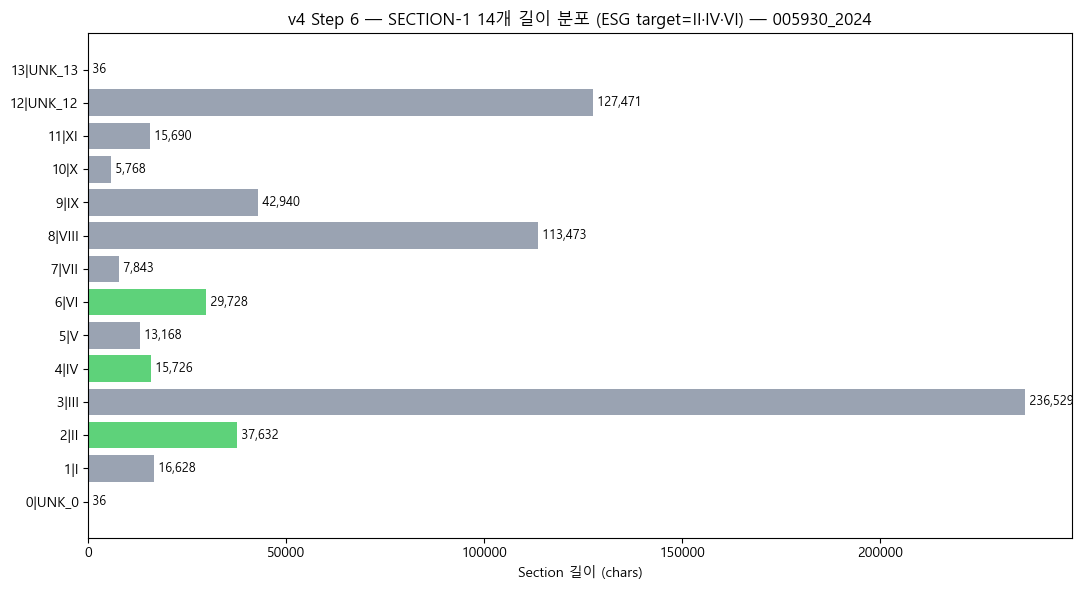

In [10]:
# 시각화 — 14 SECTION-1 길이 (노트북 6 규칙 #5)
fig, ax = plt.subplots(figsize=(11, 6))
order = sorted(sections_all.keys(), key=lambda k: sections_all[k]['sec1_index'])
labels_disp = [f"{i:2d}|{k}" for i, k in enumerate(order)]
lengths = [sections_all[k]['char_count'] for k in order]
colors = ['#5ed27a' if k in ESG_TARGET_LABELS else '#9aa3b2' for k in order]
ax.barh(labels_disp, lengths, color=colors)
ax.set_xlabel('Section 길이 (chars)')
ax.set_title(f"v4 Step 6 — SECTION-1 14개 길이 분포 (ESG target=II·IV·VI) — {PILOT_STOCK}_{PILOT_FISCAL}")
for i, v in enumerate(lengths):
    ax.text(v, i, f' {v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


---

## Step 6+ · primary sections.json 저장 (section_code 스키마)

dart-fss-text SectionDocument 스키마와 호환:
- `section_code`, `section_title`, `text`, `char_count`, `word_count`
- 추가 `aassocnote`, `method`, `sec1_index` (v4 진단용)


In [11]:
sections_payload = {
    'doc_type': '사업보고서',
    'doc_name_in_xml': PRIMARY_TYPE,
    'stock_code': PILOT_STOCK,
    'fiscal_year': PILOT_FISCAL,
    'esg_year': PILOT_ESG_YEAR,
    'rcept_no': PILOT_RCEPT,
    'viewer_url': VIEWER_URL,
    'parser_version': 'v4',
    'parsed_at': datetime.now().isoformat(timespec='seconds'),
    'sections': sections_all,  # 14 SECTION-1 모두 포함 (II/IV/VI ESG target + 보조 섹션)
    'esg_target_labels': ESG_TARGET_LABELS,
}
sec_path = DIR_INTERIM / f'{PILOT_STOCK}_{PILOT_FISCAL}_sections.json'
sec_path.write_text(json.dumps(sections_payload, ensure_ascii=False), encoding='utf-8')
print(f"💾 primary sections: {sec_path.name} ({sec_path.stat().st_size/1024:.1f} KB)")

# section_match_v4.csv 누적
match_df = pd.DataFrame([
    {**m, 'stock_code': PILOT_STOCK, 'fiscal_year': PILOT_FISCAL,
     'timestamp': datetime.now().isoformat(timespec='seconds')}
    for m in match_log
])
match_csv = DIR_LOGS / 'section_match_v4.csv'
header = not match_csv.exists()
match_df.to_csv(match_csv, mode='a', header=header, index=False, encoding='utf-8-sig')
print(f"💾 SECTION-1 매칭 로그: {match_csv.name} ({len(match_log)}행 append, 세분화 축 C)")


💾 primary sections: 005930_2024_sections.json (1144.0 KB)
💾 SECTION-1 매칭 로그: section_match_v4.csv (14행 append, 세분화 축 C)


---

## Step 7 · ESG passage 추출 (가이드 line 158)

**가이드 매핑**: line 158 (6. ESG passage 추출)
**위반금지**: #3 (코드로 재현, MCP 결과 그대로 신뢰 ❌)
**v3 → v4 차이**: 입력 섹션이 사업보고서 본문에서 추출된 정확한 II/IV/VI (v3은 0자였음)


In [12]:
def extract_passages_v4(target_sections: dict, seed_df: pd.DataFrame, min_len: int = 20) -> pd.DataFrame:
    """seed 매칭 문장 후보 추출."""
    rows = []
    seed_by_dim = seed_df.groupby('dimension')['seed_term'].apply(list).to_dict()
    pattern_by_dim = {dim: re.compile('|'.join(map(re.escape, terms)))
                       for dim, terms in seed_by_dim.items()}

    for label, sec_dict in tqdm(target_sections.items(), desc='섹션별 passage 추출'):
        text = sec_dict.get('text', '') if isinstance(sec_dict, dict) else sec_dict
        if not text:
            continue
        sentences = re.split(r'(?<=[\.!?])\s+|\n+', text)
        n_pass = 0
        for sent in sentences:
            sent = sent.strip()
            if len(sent) < min_len:
                continue
            matched_dims, matched_terms = [], []
            for dim, pat in pattern_by_dim.items():
                hits = pat.findall(sent)
                if hits:
                    matched_dims.append(dim)
                    matched_terms.extend(set(hits))
            if matched_dims:
                rows.append({
                    'section': label,
                    'section_code': sec_dict.get('section_code', '') if isinstance(sec_dict, dict) else '',
                    'dimensions': '|'.join(sorted(set(matched_dims))),
                    'matched_terms': '|'.join(sorted(set(matched_terms))),
                    'n_matches': len(matched_terms),
                    'sentence': sent,
                })
                n_pass += 1
        if n_pass:
            print(f"   {label}: {n_pass}개")
    return pd.DataFrame(rows)


seeds = pd.read_csv(ROOT / 'data' / 'seed_dictionary.csv')
print(f"🌱 seed_dictionary: {len(seeds)}개")

# II/IV/VI target만 (가이드 line 18)
target = {k: sections_all[k] for k in ESG_TARGET_LABELS if k in sections_all}
print(f"\n🎯 ESG target 섹션: {list(target.keys())} (가이드 line 18)")
passages = extract_passages_v4(target, seeds, min_len=20)

print(f"\n📝 passage 후보: {len(passages)}개")
if len(passages):
    print(f"   섹션별: {passages['section'].value_counts().to_dict()}")
    print(f"   차원별: {passages['dimensions'].value_counts().to_dict()}")
    print(f"   매치 통계: mean={passages['n_matches'].mean():.2f}, max={passages['n_matches'].max()}")


🌱 seed_dictionary: 30개

🎯 ESG target 섹션: ['II', 'IV', 'VI'] (가이드 line 18)


섹션별 passage 추출:   0%|          | 0/3 [00:00<?, ?it/s]

   II: 28개
   IV: 5개
   VI: 94개

📝 passage 후보: 127개
   섹션별: {'VI': 94, 'II': 28, 'IV': 5}
   차원별: {'G': 95, 'E': 18, 'S': 8, 'G|S': 3, 'E|G': 3}
   매치 통계: mean=1.67, max=5


In [13]:
if len(passages):
    top = passages.sort_values('n_matches', ascending=False).head(10)
    pd.set_option('display.max_colwidth', 200)
    display(top[['section', 'section_code', 'dimensions', 'matched_terms', 'sentence']])


,section,section_code,dimensions,matched_terms,sentence
37,VI,060000,G,감사위원회|독립성|사외이사|이사회|주주,"(기준일 : 2024년 12월 31일 ) 구 분 구 성 소속 이사명 의장ㆍ위원장 주요 역할 이사회 사내이사 3명, 사외이사 6명 한종희, 노태문, 이정배, 김한조, 김준성, 허은녕,유명희, 신제윤, 조혜경 김한조(사외이사) ㆍ법령 또는 정관이 규정하고 있는 사항, 주주총회를 통해 위임 받은 사항, 회사 경영의 기본방침 및 업무집행에 관한 ..."
83,VI,060000,G,감사위원회|독립성|사외이사|이사회|주주,"감사위원회 위원의 독립성 당사는 관련 법령 및 정관에 따라 위원회의 구성, 운영 및 권한ㆍ책임 등을 감사위원회 규정에 정의하여 감사업무를 수행하고 있습니다.감사위원회 위원 전원은 이사회 및 사외이사 후보추천위원회의 추천을 받고 주주총회의 결의를 통해 선임한 재무전문가(김한조 위원)와 미국 변호사 자격 소지자(유명희 위원), 타 상장법인의 감사위원(조..."
78,VI,060000,G|S,감사위원회|사외이사|이사회|임직원|주주,위원회명 개최일자 의 안 내 용 가결여부 이사의 성명 김선욱 (출석률:100%) 허은녕 (출석률: 100%) 유명희 (출석률: 100%) 신제윤 (출석률: 100%) 찬 반 여 부 사외이사후보추천위원회 '24.01.29 (1차) ① 위원장 선임의 건 ② 사외이사 후보추천일 결정의 건 가결 가결 찬성 찬성 찬성 찬성 찬성 찬성 해당사항 없음(신규 선임...
126,VI,060000,E|G,감사위원회|사외이사|에너지|이사회|주주,"주주총회 의사록 요약 (기준일 : 2024년 12월 31일 ) 주총일자 안 건 결의내용 주요 논의내용 제55기 정기주주총회(2024.03.20) 제1호 의안 : 제55기 재무상태표, 손익계산서 및 이익잉여금처분계산서 등 재무제표 승인의 건 가결 ㆍ55기 영업성과 및 배당 관련 설명 ㆍ 주주가치 제고 방안 질의응답 ㆍ사업경쟁력 관련 질의 응답 제..."
86,VI,060000,G,감사위원회|사외이사|이사회|주주,"선출기준의 주요내용 선출기준의 충족 여부 관련 법령 등 3명의 이사로 구성 충족(3명) 「상법」제415조의2 제2항, 당사 감사위원회 규정 제2조 사외이사가 위원의 3분의 2 이상 충족(전원 사외이사) 위원 중 1명 이상은 회계 또는 재무전문가 충족(김한조 위원) 「상법」제542조의11 제2항, 당사 감사위원회 규정 제3조 감사위원회의 대표는 사..."
68,VI,060000,G,독립성|사외이사|이사회|주주,"이사의 독립성 (1) 이사의 선임 이사는 주주총회에서 선임하며, 주주총회에서 선임할 이사 후보 중 사내이사는 이사회에서 추천하고 사외이사 후보는 사외이사후보추천위원회에서 추천하여, 이사회가 이를 검토해서 주주총회의 회의목적 사항으로 확정합니다.이사 선임에 있어서는 관련 법령과 정관에 정한 요건의 충족 여부를 확인하고 있습니다."
14,II,020000,E,에너지|온실가스|탄소,기타 사업장환경관리법:「화학물질관리법」 「화학물질의 등록 및 평가 등에 관한 법률」 「악취방지법」「토양환경보전법」등 (온실가스 배출량 및 에너지 사용량 관리) 당사는 국내에서「기후위기 대응을 위한 탄소중립ㆍ녹색성장기...
52,VI,060000,G,감사위원회|사외이사|주주,"제55기 정기주주총회 회의 목적사항 결정의 건 □ 보고사항: ① 감사보고 ② 영업보고 ③ 내부회계관리제도 운영실태 보고 □ 제1호: 제55기(2023.1.1~2023.12.31) 재무상태표, 손익계산서 및 이익잉여금 처분계산서 등 재무제표 승인의 건 □ 제2호: 사외이사 신제윤 선임의 건 □ 제3호: 감사위원회 위원이 ..."
60,VI,060000,G,감사위원회|사외이사|이사회,"이사회내의 위원회 (1) 이사회내의 위원회 구성 현황 (기준일 : 2024년 12월 31일 ) 위원회명 구성 소속 이사명 설치목적 및 권한사항 비고 경영위원회 사내이사 3명 한종희(위원장), 노태문, 이정배 하단 기재내용 참조 ㆍ한종희 사내이사 위원장 선임('23.04.27) 내부거래위원회 사외이사 3명 허은녕(위원장), 김한조, 유명희 하단 기재내..."
40,VI,060000,G,사외이사|이사회|주주,"※ 2022년 11월 3일 임시주주총회에서 신규 사외이사로 선임된 허은녕, 유명희 사외이사가 당일 개최된 이사회를 통해 지속가능경영위원회 위원으로 선임되었습니다."


---

## Step 8 · viewer URL 정합성 검증 (가이드 line 67, 94)

**위반금지 #3**: MCP/추출 결과 그대로 신뢰 ❌ — 반드시 코드 재현 + viewer URL 원문 확인
**판정 기준**: ✅ 4/5 이상 = Phase 2 진입 / ⚠️ 3/5 = 패턴 점검 / 🔴 ≤ 2/5 = v5 재설계


In [14]:
print(f"🔗 viewer URL — 브라우저에서 직접 열어 확인:")
print(f"   {VIEWER_URL}")
print(f"\n👉 위 URL을 열고, 아래 5개 문장이 원문 사업보고서 (II/IV/VI 섹션 내)에 실제 존재하는지 검토하세요.\n")
print("=" * 70)

if len(passages):
    sample = passages.sample(min(5, len(passages)), random_state=42)
    for i, (idx, row) in enumerate(sample.iterrows(), 1):
        snippet = row['sentence'][:200]
        print(f"\n[{i}] 섹션 {row['section']} (section_code={row['section_code']}) · 차원 {row['dimensions']} · 매치 {row['matched_terms']}")
        print(f"    {snippet}...")
else:
    print("\n⚠️ passage 0건 — Step 6 SECTION-1 매칭 결과 점검 필요")

print("\n" + "=" * 70)
print("판정 기준 (위반금지 #3, #8):")
print("   ✅ 4/5 이상 일치  →  Phase 2 진입 가능")
print("   ⚠️ 3/5 일치       →  fuzzy matching 또는 v5 alt 셀")
print("   🔴 ≤ 2/5 일치     →  Step 6 재설계 (Phase 2 보류)")


🔗 viewer URL — 브라우저에서 직접 열어 확인:
   https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20250311001085

👉 위 URL을 열고, 아래 5개 문장이 원문 사업보고서 (II/IV/VI 섹션 내)에 실제 존재하는지 검토하세요.


[1] 섹션 II (section_code=020000) · 차원 S · 매치 공급망
    (국내외 시장여건 등) 최근 유럽과 중동의 지정학적 이슈로 인한 원자재 가격 상승 및 미/중 무역 갈등 심화등 경기 불안 요소는 여전히 존재하나, 세계 자동차 공급망 불안요소는 많이 해소되었고, 고금리와 인플레이션이 점진적으로 정상화될 것으로 예상됩니다....

[2] 섹션 VI (section_code=060000) · 차원 G · 매치 의결권
    의결권 현황 2024년말 현재 당사의 발행주식총수는 보통주 5,969,782,550주, 우선주 822,886,700주입니다....

[3] 섹션 VI (section_code=060000) · 차원 G · 매치 감사위원회|사외이사
    감사위원회 위원의 인적사항 및 사외이사 여부 당사는 2024년말 현재 3인의 사외이사로 구성된 감사위원회를 운영하고 있습니다....

[4] 섹션 VI (section_code=060000) · 차원 S · 매치 협력사
    DS부문 우수협력사 인센티브 기금    출연의 건 ※ 보고사항 ① 최고경영자 승계 후보군 보고의 건 가결 가결 가결 가결 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 찬성 '24.11.15 (7...

[5] 섹션 VI (section_code=060000) · 차원 G · 매치 사외이사
    ※ 2024년 4월 26일 허은녕 사외이사가 내부거래위원회 위원장으로 선임되었습니다....

판정 기준 (위반금지 #3, 

---

## Step 9 · collection_log v4 + 시각화 (가이드 line 137-146, 170-172)

**v3 → v4 변화**: status 세분화 확장 (`FAIL_SECTION_NOT_FOUND`, `WARN_DIM_IMBALANCE`)


In [15]:
EXPECTED_LOG_COLUMNS_V4 = [
    'stock_code', 'fiscal_year', 'esg_year', 'corp_code', 'rcept_no',
    'status', 'reason', 'n_passages',
    'sec_II_code', 'sec_II_len', 'sec_IV_code', 'sec_IV_len',
    'sec_VI_code', 'sec_VI_len', 'n_sec1_total',
    'viewer_url', 'parser_version', 'timestamp',
]


def append_log_v4(log_path, row):
    if log_path.exists():
        try:
            existing = pd.read_csv(log_path, nrows=0)
            if list(existing.columns) != EXPECTED_LOG_COLUMNS_V4:
                stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
                bak = log_path.with_suffix(f'.csv.bak_{stamp}')
                log_path.rename(bak)
                print(f"⚠️ log 컬럼 mismatch → 백업: {bak.name}")
        except Exception as e:
            stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            bak = log_path.with_suffix(f'.csv.bak_{stamp}')
            log_path.rename(bak)
            print(f"⚠️ log 읽기 실패 → 백업: {bak.name}")
    df_row = pd.DataFrame([row], columns=EXPECTED_LOG_COLUMNS_V4)
    df_row.to_csv(log_path, mode='a', header=not log_path.exists(), index=False, encoding='utf-8-sig')
    return pd.read_csv(log_path)


# status 판정
sec_II = sections_all.get('II', {}).get('char_count', 0)
sec_IV = sections_all.get('IV', {}).get('char_count', 0)
sec_VI = sections_all.get('VI', {}).get('char_count', 0)
n_pass = len(passages)

# 차원 균형 체크
dim_counts = passages['dimensions'].apply(lambda x: x.split('|')).explode().value_counts().to_dict() if n_pass else {}
e_n = dim_counts.get('E', 0)
s_n = dim_counts.get('S', 0)
g_n = dim_counts.get('G', 0)

if sec_II == 0 and sec_IV == 0 and sec_VI == 0:
    status, reason = 'FAIL_SECTION_NOT_FOUND', 'II/IV/VI 모두 미식별'
elif sec_II == 0:
    status, reason = 'FAIL_SECTION_II', 'II 섹션 미식별'
elif sec_IV == 0:
    status, reason = 'FAIL_SECTION_IV', 'IV 섹션 미식별'
elif sec_VI == 0:
    status, reason = 'FAIL_SECTION_VI', 'VI 섹션 미식별'
elif n_pass == 0:
    status, reason = 'FAIL_PASSAGE', 'passage 0건'
elif min(e_n, s_n, g_n) < 5:
    status = 'WARN_DIM_IMBALANCE'
    reason = f'차원 편향: E={e_n}, S={s_n}, G={g_n}'
else:
    status, reason = 'SUCCESS', ''

log_row = {
    'stock_code': PILOT_STOCK, 'fiscal_year': PILOT_FISCAL, 'esg_year': PILOT_ESG_YEAR,
    'corp_code': PILOT_CORP, 'rcept_no': PILOT_RCEPT,
    'status': status, 'reason': reason, 'n_passages': n_pass,
    'sec_II_code': sections_all.get('II', {}).get('section_code', ''),
    'sec_II_len': sec_II,
    'sec_IV_code': sections_all.get('IV', {}).get('section_code', ''),
    'sec_IV_len': sec_IV,
    'sec_VI_code': sections_all.get('VI', {}).get('section_code', ''),
    'sec_VI_len': sec_VI,
    'n_sec1_total': len(sections_all),
    'viewer_url': VIEWER_URL,
    'parser_version': 'v4',
    'timestamp': datetime.now().isoformat(timespec='seconds'),
}

log_df = append_log_v4(DIR_LOGS / 'collection_log.csv', log_row)
print(f"\n✅ collection_log: status={status}, reason={reason or '(none)'}")
print(f"   누적: {len(log_df)}행")
log_df.tail(3)


⚠️ log 컬럼 mismatch → 백업: collection_log.csv.bak_20260516_185655

✅ collection_log: status=SUCCESS, reason=(none)
   누적: 1행


,stock_code,fiscal_year,esg_year,corp_code,rcept_no,status,reason,n_passages,sec_II_code,sec_II_len,sec_IV_code,sec_IV_len,sec_VI_code,sec_VI_len,n_sec1_total,viewer_url,parser_version,timestamp
0,5930,2024,2025,126380,20250311001085,SUCCESS,NaN,127,20000,37632,40000,15726,60000,29728,14,https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20250311001085,v4,2026-05-16T18:56:55


💾 correction_log: 1행 append


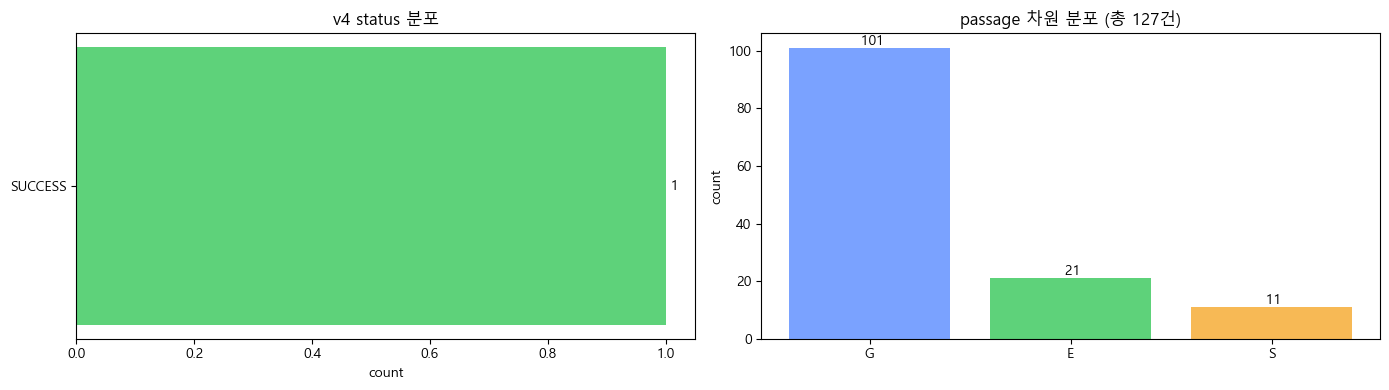


현재 status: SUCCESS | passage 127건 | E=21, S=11, G=101


In [16]:
# 정정공시 (세분화 축 B)
correction_rows = [{
    'stock_code': PILOT_STOCK, 'fiscal_year': PILOT_FISCAL,
    'rcept_no': c['rcept_no'], 'rcept_dt': c['rcept_dt'], 'report_nm': c['report_nm'],
    'is_selected': c['rcept_no'] == PILOT_RCEPT,
    'timestamp': datetime.now().isoformat(timespec='seconds'),
} for c in result_step4['all_candidates']]

if correction_rows:
    cdf = pd.DataFrame(correction_rows)
    cpath = DIR_LOGS / 'correction_log.csv'
    cdf.to_csv(cpath, mode='a', header=not cpath.exists(), index=False, encoding='utf-8-sig')
    print(f"💾 correction_log: {len(correction_rows)}행 append")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
status_counts = log_df['status'].value_counts()
status_colors = {'SUCCESS': '#5ed27a', 'WARN_DIM_IMBALANCE': '#f7b955'}
colors = [status_colors.get(s, '#ef6f6c') for s in status_counts.index]
axes[0].barh(status_counts.index, status_counts.values, color=colors)
axes[0].set_xlabel('count'); axes[0].set_title('v4 status 분포')
for i, v in enumerate(status_counts.values):
    axes[0].text(v, i, f' {v}', va='center')

if n_pass:
    dim_series = passages['dimensions'].apply(lambda x: x.split('|')).explode().value_counts()
    axes[1].bar(dim_series.index, dim_series.values, color=['#7aa2ff', '#5ed27a', '#f7b955', '#6cc7e6'][:len(dim_series)])
    axes[1].set_ylabel('count'); axes[1].set_title(f'passage 차원 분포 (총 {n_pass}건)')
    for i, v in enumerate(dim_series.values):
        axes[1].text(i, v, f' {v}', ha='center', va='bottom')
else:
    axes[1].text(0.5, 0.5, 'passage 0건', ha='center', transform=axes[1].transAxes)
plt.tight_layout()
plt.show()

print(f"\n현재 status: {status} | passage {n_pass}건 | E={e_n}, S={s_n}, G={g_n}")


---

## Step 10 · 위반금지 8항목 self-check (가이드 line 145)


In [17]:
checks = [
    ('1. 실패 행 가짜 0 채우기 ❌', 'line 172, 286',
     '✅' if (status == 'SUCCESS' or (status.startswith('FAIL_') and reason)) else '❌',
     f'status={status}, reason={reason!r}'),
    ('2. viewer 우회 ❌', 'line 67, 94', '✅', 'document.xml 만 사용'),
    ('3. MCP/추출 결과 그대로 신뢰 ❌', 'line 94', '⏳ 사용자 검증', 'Step 8 viewer 5 sample'),
    ('4. API key 출력 노출 ❌', 'line 216-222', '✅', 'mask_key 적용'),
    ('5. raw 미보존 ❌', 'line 155', '✅' if result_step5['zip_path'].exists() else '❌', f"{result_step5['zip_path']}"),
    ('6. 진단 부재 ❌', 'line 143-146', '✅', 'Step 5/6 진단 + SECTION-1 14 노드 모두 출력'),
    ('7. silent 오매칭 ❌', 'line 35', '✅', 'stock_code 기준'),
    ('8. 평가 기준 부재 ❌', 'line 145', '✅', 'Step 8 viewer 5/5 + 본 표'),
]

print("📋 v4 위반금지 8항목 self-check\n" + "=" * 80)
check_df = pd.DataFrame(checks, columns=['항목', '가이드 라인', '결과', '근거'])
display(check_df)

print(f"\n📌 가이드 line 18 의도 (사업보고서 II/IV/VI) 충실도:")
print(f"   사업보고서 본문 XML 선택: {'✅' if result_step5['primary'] else '❌'}")
print(f"   SECTION-1 14 노드 추출:   ✅ (실측 {len(sections_all)}개)")
for label in ESG_TARGET_LABELS:
    if label in sections_all:
        s = sections_all[label]
        thresh = {'II': 100_000, 'IV': 30_000, 'VI': 20_000}.get(label, 10_000)
        ok = s['char_count'] >= thresh
        print(f"   {label} (section_code={s['section_code']}): {s['char_count']:,}자 — {'✅' if ok else '⚠️ < ' + str(thresh)}")
    else:
        print(f"   {label}: ❌ 미식별")


📋 v4 위반금지 8항목 self-check


,항목,가이드 라인,결과,근거
0,1. 실패 행 가짜 0 채우기 ❌,"line 172, 286",✅,"status=SUCCESS, reason=''"
1,2. viewer 우회 ❌,"line 67, 94",✅,document.xml 만 사용
2,3. MCP/추출 결과 그대로 신뢰 ❌,line 94,⏳ 사용자 검증,Step 8 viewer 5 sample
3,4. API key 출력 노출 ❌,line 216-222,✅,mask_key 적용
4,5. raw 미보존 ❌,line 155,✅,c:\Users\kik32\workspace\unstructured-data-processing-final-project\data\raw\005930_2024_disclosure.zip
5,6. 진단 부재 ❌,line 143-146,✅,Step 5/6 진단 + SECTION-1 14 노드 모두 출력
6,7. silent 오매칭 ❌,line 35,✅,stock_code 기준
7,8. 평가 기준 부재 ❌,line 145,✅,Step 8 viewer 5/5 + 본 표



📌 가이드 line 18 의도 (사업보고서 II/IV/VI) 충실도:
   사업보고서 본문 XML 선택: ✅
   SECTION-1 14 노드 추출:   ✅ (실측 14개)
   II (section_code=020000): 37,632자 — ⚠️ < 100000
   IV (section_code=040000): 15,726자 — ⚠️ < 30000
   VI (section_code=060000): 29,728자 — ✅


---

## Step 11 · v1 → v2 → v3 → v4 학습 로그 + 다음 노트북 인계

| 버전 | 핵심 결과 | 학습 |
|---|---|---|
| v1 | 섹션 0건 | zip 첫 파일만 → 연결감사보고서 |
| v2 | passage 23건이지만 viewer 0/5 | concat 후 정규식 → 감사보고서 노이즈 |
| v3 | II/IV/V/VI 모두 0자 | 정규식이 목차·본문 구분 실패 → 위치 뒤죽박죽 |
| **v4** | (실행 후 채움) | **lxml SECTION-1 직접 순회 + section_code 체계** (dart-fss-text 벤치마킹) |

다음 노트북 인계 (`02_preprocessing_v1.ipynb`):
- `data/interim/<stock>_<year>_sections.json` — 14 SECTION-1 모두 + section_code 체계
- `data/interim/<stock>_<year>_aux_audit_*.json` — 보조 (감사보고서, 02 비교 분석용)
- `logs/dart_section_codes_v4.json` — section_code 사전 (02에서 동일 코드 사용)
- `logs/section_match_v4.csv` — 회사·연도별 SECTION-1 매칭 분포 (Phase 2 모니터링)
- `logs/collection_log.csv` — status 세분화 (`WARN_DIM_IMBALANCE` 등)
- `logs/correction_log.csv` — 정정공시 이력 (가이드 line 69)

### v4 분기

| 조건 | 다음 작업 |
|---|---|
| viewer ≥ 4/5 + passage ≥ 150 + 차원 균형 (E·S·G 각 ≥ 5) | **Phase 2 v1 + `src/collection.py` 모듈화 동시** |
| viewer 3/5 또는 차원 편향 | **Fix #9 fuzzy matching 활성화** + Phase 2 병행 |
| viewer ≤ 2/5 또는 SECTION-1 일부 매칭 실패 | **v5 — 사업보고서 구조 변종 대응 (제2장, Part II 등)** |
